# Simulating quadcopter dynamics using tinympc model
In this demonstration, we showcase an interactive Python workflow using TinyMPC. You can generate C++ code and engage with it seamlessly within the Python environment. This example guides you through the entire workflow, beginning with the quadrotor's nonlinear dynamics. The process closely mirrors the steps taken for deploying MPC on the Crazyflie.

If any issues arise, restart the kernel.

Load necessary packages, make sure to install `tinympc` ([README.md](../README.md))

In [1]:
import tinympc
import math
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import pandas as pd
from matplotlib.cm import rainbow
from util.traj_circle_500hz import get_refs
from util.multisines import multisine_clip
from util.rodrigues import rodrigues_to_euler, euler_to_rodrigues

In [3]:
def plot_ref(xref, eangles, nx):
    fig, axes = plt.subplots(nrows=2,ncols=4, figsize=(18, 8))

    #xlabels = ['x','y','z','theta','phi','psi','vx','vy','vz','vtheta','vphi','vpsi']
    xlabels = ['$x$','$y$','$z$','$\phi$','$\\theta$','$\psi$','$v_x$','$v_y$','$v_z$','$v_\phi$','$v_{\\theta}$','$v_\psi$']
    titles = ['position', 'orientation (Rodrigues)', 'velocity', 'angular rate (Rodrigues)']
    cols = ["#0072BD","#D95319","#EDB120","#7E2F8E","#77AC30","#4DBEEE","#0072BD","#D95319","#EDB120","#7E2F8E","#77AC30","#4DBEEE"]
    axes = axes.flatten()
    for jj in range(4):
        ax = axes[jj]
        for ii in range(jj*3,(jj+1)*3):
            ax.plot(tx, X_ref[:,ii], label=xlabels[ii], color=cols[ii])
            legend = ax.legend(loc='lower left')
            ax.set_title(titles[jj])
            ax.set_xlabel('t')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # rect: left, bottom, right, top
    
    euler_lab = ['roll', 'pitch', 'yaw']
    ax=axes[5]
    for ii in range(3):
        ax.plot(tx,Eangles[:,ii], label=euler_lab[ii], color=cols[3+ii])
    ax.set_xlabel('t')
    ax.set_ylabel('angle (rad)')
    ax.set_title('orientation (Euler angle)')
    legend = ax.legend(loc='lower left')
    
    colors = rainbow(np.linspace(0, 1, nx))
    ax = axes[6]
    scat = ax.scatter(X_ref[:,0],X_ref[:,1], color=colors)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_xlim(-2,2)
    ax.set_ylim(-2,2)
    sm = plt.cm.ScalarMappable(cmap=rainbow)
    sm.set_clim(vmin=tx[0], vmax=tx[-1])
    fig.colorbar(sm, ax=ax)
    
    for ii in range(0,nx,10):
        # arrow from xytext to xy
        #angles = rodrigues_to_euler(X_ref[ii,3:6])
        #yaw = angles[2]
        yaw = Eangles[ii,2]
        ax.annotate("", xytext=(X_ref[ii,0],X_ref[ii,1]), xy=(X_ref[ii,0]+0.3*np.sin(yaw),X_ref[ii,1]+0.3*np.cos(yaw)),
                    arrowprops=dict(arrowstyle="->"))
    ax.set_title('position (x,y) and yaw')
    
    axes[7].remove()
    ax = fig.add_subplot(2, 3, 6, projection='3d')
    ax.scatter(X_ref[:,0], X_ref[:,1], X_ref[:,2], color=colors)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_zlabel('$z$')
    ax.set_xlim(-2,2)
    ax.set_ylim(-2,2)
    ax.set_zlim(-0.5,3.5)
    ax.view_init(elev=20., azim=-35)

    plt.show()

# function to visualize the trajectory
def visualize_trajectory(x_all):
    # Set up the figure and axis for plotting
    fig, ax = plt.subplots(2, 1)

    # Plot the trajectory
    x_all = np.array(x_all)
    nsteps = len(x_all)
    steps = np.arange(nsteps)
    ax[0].plot(steps, x_all[:, 0], label="x", linewidth=2)
    ax[0].plot(steps, x_all[:, 1], label="y", linewidth=2)
    ax[0].plot(steps, x_all[:, 2], label="z", linewidth=2)
    ax[0].legend()
    ax[0].title.set_text("Position")

    ax[1].plot(steps, x_all[:, 3], label="q0", linewidth=2)
    ax[1].plot(steps, x_all[:, 4], label="q1", linewidth=2)
    ax[1].plot(steps, x_all[:, 5], label="q2", linewidth=2)
    ax[1].plot(steps, x_all[:, 6], label="q3", linewidth=2)
    ax[1].legend()
    ax[1].title.set_text("Attitude")
    plt.show()

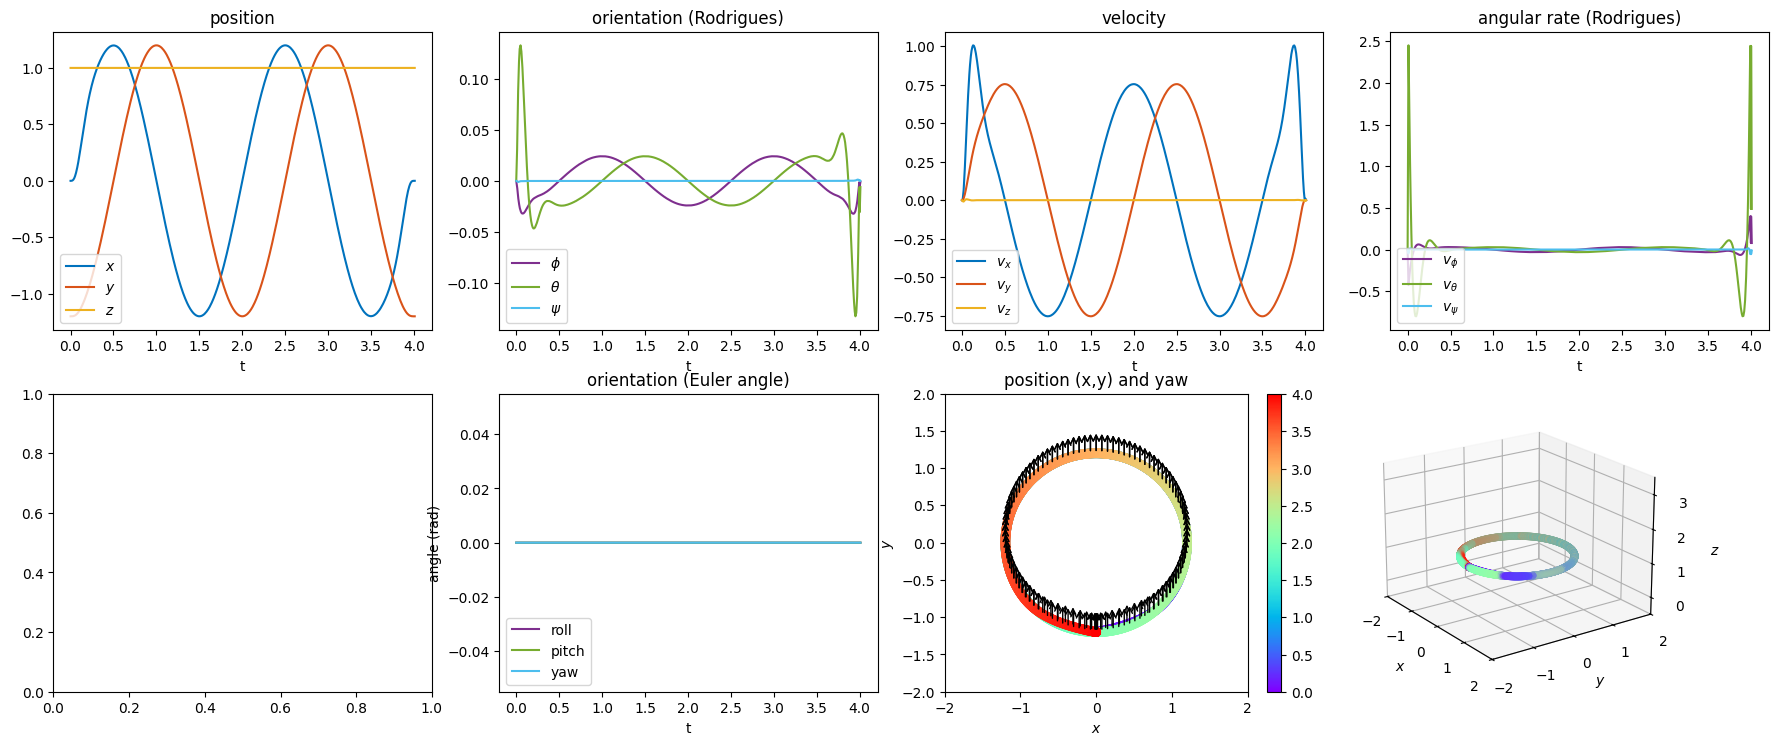

[-0.  -1.2  1. ]
[-0.  -1.2  1. ]


In [4]:
X_ref, U_ref = get_refs()
nx = X_ref.shape[0]
tx = np.linspace(0,(nx-1)/500,nx)
Eangles = np.zeros((nx,3))
plot_ref(X_ref, Eangles, nx)

print(X_ref[0,0:3])
print(X_ref[-1,0:3])

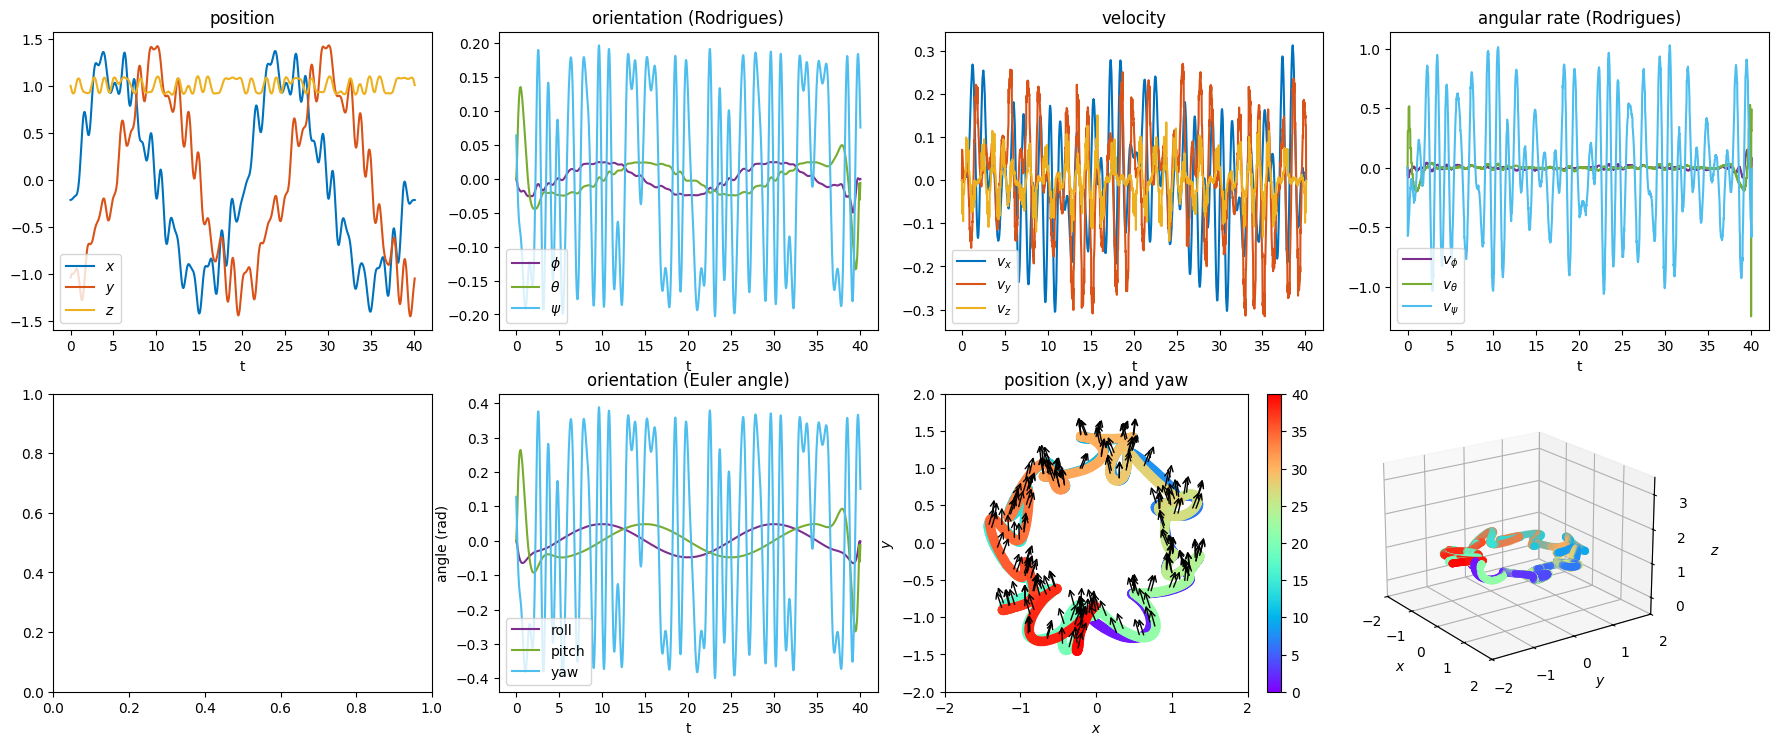

Number of samples: 2005


In [39]:
nreps = 1
freq = 50.0

X_ref, U_ref = get_refs()
X_ref = np.tile(X_ref, ([nreps,1]))

nx = X_ref.shape[0]
nu = U_ref.shape[0]
tx = np.linspace(0,(nx-1)/freq,nx)

Eangles = np.zeros((nx,3))
Eangles = np.apply_along_axis(rodrigues_to_euler, 1, X_ref[:,3:6]) # XYZ convention (RPY)

#dist_amplitude = [0.3, 0.3, 0.3, 0.5]
dist_amplitude = np.array([0.3, 0.3, 0.1, 0.4]) # 0.15 for z
seeds = [762, 10, 1221, 35]
#seeds = [33, 22, 13, 5]
T = nx/freq # 2005/500
Nt = nx
#Nt=2005
P = 20 # 20
f0 = 1 # in Hz

for ii,refn in enumerate([0,1,2,5]):
    seed=seeds[ii]

    u, t = multisine_clip(T, Nt, P, f0, seed, False)
    u = np.real(u)
    u = u/np.max(np.abs(u))

    if refn==5:
        Eangles[:,2] = Eangles[:,2] + dist_amplitude[ii]*u
        Rodr = np.apply_along_axis(euler_to_rodrigues, 1, Eangles) 
        X_ref[:,3:6] = Rodr
    else:
        # X_ref[:,refn] = X_ref[:,refn] + dist_amplitude[ii]*u
        X_ref[:,refn] = X_ref[:,refn] + dist_amplitude[ii]*u


# velocities/attitudes (for illustration, will not be used for control)
X_ref[1:-1,6] = freq*(X_ref[1:-1,0] - X_ref[0:-2,0])/6 # x
X_ref[1:-1,7] = freq*(X_ref[1:-1,1] - X_ref[0:-2,1])/6 # y
X_ref[1:-1,8] = freq*(X_ref[1:-1,2] - X_ref[0:-2,2])/6 # z

X_ref[1:-1,9] = freq*(X_ref[1:-1,3] - X_ref[0:-2,3]) # phi
X_ref[1:-1,10] = freq*(X_ref[1:-1,4] - X_ref[0:-2,4]) # theta
X_ref[1:-1,11] = freq*(X_ref[1:-1,5] - X_ref[0:-2,5]) # psi


#reference = pd.DataFrame(X_ref[:,0:6], columns=["x","y","z","rod_phi","rod_theta","rod_psi"])
#reference.to_csv(f"test_ref_traj.csv", float_format="%.4f", index=False, index_label=False)

plot_ref(X_ref, Eangles, nx)
print(f'Number of samples: {X_ref.shape[0]}')

## Quadrotor Dynamics
Build the quadrotor nonlinear dynamics and linearize around the hovering state using `autograd`. 

In [40]:
import autograd.numpy as np
import autograd.numpy as sqrt
from autograd.numpy.linalg import norm
from autograd.numpy.linalg import inv
from autograd import jacobian
from autograd.test_util import check_grads
np.set_printoptions(precision=3, suppress=True)

# autograd does not work with np.block

#Quaternion stuff, check `Planning with Attitude` paper for more details
def hat(v):
    return np.array([[0, -v[2], v[1]],
                     [v[2], 0, -v[0]],
                     [-v[1], v[0], 0.0]])

def L(q):
    s = q[0]
    v = q[1:4]
    up = np.hstack([s, -v])
    down = np.hstack([v.reshape(3,1), s*np.eye(3) + hat(v)])
    L = np.vstack([up,down])
    return L

T = np.diag([1.0, -1, -1, -1])
H = np.vstack([np.zeros((1,3)), np.eye(3)])

def qtoQ(q):
    return H.T @ T @ L(q) @ T @ L(q) @ H

def G(q):
    return L(q) @ H

def rptoq(phi):
    return (1./np.sqrt(1+phi.T @ phi)) * np.hstack([1, phi]) # changed from sqrt to np.sqrt

def qtorp(q):
    return q[1:4]/q[0]

def E(q):
    up = np.hstack([np.eye(3), np.zeros((3,3)), np.zeros((3,6))])
    mid = np.hstack([np.zeros((4,3)), G(q), np.zeros((4,6))])
    down = np.hstack([np.zeros((6,3)), np.zeros((6,3)), np.eye(6)])
    E = np.vstack([up, mid, down])
    return E

# Quadrotor parameters
mass = 0.035  # mass
J = np.array([[1.66e-5, 0.83e-6, 0.72e-6], [0.83e-6, 1.66e-5, 1.8e-6], [0.72e-6, 1.8e-6, 2.93e-5]])  # inertia
g = 9.81  # gravity
# thrustToTorque = 0.005964552
thrustToTorque = 0.0008  # thrust to torque ratio
el = 0.046/1.414213562  # arm length
scale = 65535  # PWM scale
kt = 2.245365e-6*scale # thrust coefficient, u is PWM in range [0...1], 0 is no thrust, 1 is max thrust
km = kt*thrustToTorque # moment coefficient

freq = 50.0 # 50.0 # >>>>>>>> CONTROL FREQUENCY <<<<<<<<<<
h = 1/freq #50 Hz 

Nx1 = 13        # number of states (quaternion)
Nx = 12         # number of states (linearized): x, y, z, Rodriguez 3-parameters (p, q, r), vx, vy, vz, wx, wy, wz
Nu = 4          # number of controls (motor pwm signals, 0-1)

##############################################
##############################################

# Quadrotor dynamics -- single rigid body dynamics
def quad_dynamics(x, u):
    r = x[0:3]  # position
    q = x[3:7]/norm(x[3:7])  # normalize quaternion
    v = x[7:10]  # linear velocity
    omg = x[10:13]  # angular velocity
    Q = qtoQ(q)  # quaternion to rotation matrix

    dr = v
    dq = 0.5*L(q)@H@omg
    dv = np.array([0, 0, -g]) + (1/mass)*Q@np.array([[0, 0, 0, 0], [0, 0, 0, 0], [kt, kt, kt, kt]])@u
    domg = inv(J)@(-hat(omg)@J@omg + np.array([[-el*kt, -el*kt, el*kt, el*kt], [-el*kt, el*kt, el*kt, -el*kt], [-km, km, -km, km]])@u)
    
    return np.hstack([dr, dq, dv, domg])

# RK4 integration with zero-order hold on u
def quad_dynamics_rk4(x, u):
    f1 = quad_dynamics(x, u)
    f2 = quad_dynamics(x + 0.5*h*f1, u)
    f3 = quad_dynamics(x + 0.5*h*f2, u)
    f4 = quad_dynamics(x + h*f3, u)
    xn = x + (h/6.0)*(f1 + 2*f2 + 2*f3 + f4)
    xnormalized = xn[3:7]/norm(xn[3:7])  # normalize quaternion
    return np.hstack([xn[0:3], xnormalized, xn[7:13]])

# Linearize the dynamics around x0, u0
A_jac = jacobian(quad_dynamics_rk4, 0)  # jacobian wrt x
B_jac = jacobian(quad_dynamics_rk4, 1)  # jacobian wrt u

# Hovering state and control input
rg = np.array([0.0, 0, 0.0])
qg = np.array([1.0, 0, 0, 0])
vg = np.zeros(3)
omgg = np.zeros(3)
x0 = np.hstack([rg, qg, vg, omgg])
u0 = (mass*g/kt/4)*np.ones(4)  # ~each motor thrust to compensate for gravity
print(x0, u0)

check_grads(quad_dynamics_rk4, modes=['rev'], order=2)(x0, u0)

Anp1 = A_jac(x0, u0)  # jacobian of the dynamics wrt x at x0, u0
Bnp1 = B_jac(x0, u0)  # jacobian of the dynamics wrt u at x0, u0

# `Planning with Attitude` trick, attitude Jacobians
Anp = E(qg).T @ Anp1 @ E(qg) 
Bnp = E(qg).T @ Bnp1
print("A = \n", Anp)
print("B = \n", Bnp)

##############################################
##############################################

## Code Generation

# Defining the class and compiling original TinyMPC code to get a generic shared/dynamic library.

# Setup of problem data and settings for TinyMPC.
    
prob = tinympc.TinyMPC()

n = 12  # number of states == Nx
m = 4   # number of inputs == Nu
N = 10  # horizon length

# Choose Q and R matrices based on Bryson's rule 
max_dev_x = np.array([0.1, 0.1, 0.1,  0.5, 0.5, 0.03,  0.5, 0.5, 0.5,  0.7, 0.7, 0.2])
max_dev_u = np.array([0.5, 0.5, 0.5, 0.5])/6

Q = np.diag(1./max_dev_x**2)  # diagonal of state cost
R = np.diag(1./max_dev_u**2)  # diagonal of input cost
rho = 0.1  # ADMM penalty parameter

x_min = np.tile([-1000.0], (n, N))       # state constraints
x_max = np.tile([1000.0], (n, N))        # state constraints
u_min = np.tile([-u0[0]], (m, N-1))      # input constraints
u_max = np.tile([1.0-u0[0]], (m, N-1))   # input constraints

abs_pri_tol = 1.0e-3    # absolute primal tolerance
abs_dua_tol = 1.0e-3   # absolute dual tolerance
max_iter = 100          # maximum number of iterations
check_termination = 1   # whether to check termination and period

# Setup problem data
prob.setup(Anp, Bnp, Q, R, N, rho=rho, x_min=x_min, x_max=x_max, u_min=u_min, u_max=u_max, 
           abs_pri_tol=abs_pri_tol, abs_dua_tol=abs_dua_tol, max_iter=max_iter, check_termination=check_termination)


##############################################
##############################################

# After define the problem, we generate the tailored code with above data. 
# Here we compile it for interactive Python script but you can use it directly for your applications/systems

output_dir = "./generated_code"  # Output in current directory
prob.codegen(output_dir, verbose=1)

[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.] [0.583 0.583 0.583 0.583]
A = 
 [[ 1.     0.     0.     0.     0.004  0.     0.02   0.     0.     0.
   0.     0.   ]
 [ 0.     1.     0.    -0.004  0.     0.     0.     0.02   0.    -0.
   0.     0.   ]
 [ 0.     0.     1.     0.     0.     0.     0.     0.     0.02   0.
   0.     0.   ]
 [ 0.     0.     0.     1.     0.     0.     0.     0.     0.     0.01
   0.     0.   ]
 [ 0.     0.     0.     0.     1.     0.     0.     0.     0.     0.
   0.01   0.   ]
 [ 0.     0.     0.     0.     0.     1.     0.     0.     0.     0.
   0.     0.01 ]
 [ 0.     0.     0.     0.     0.392  0.     1.     0.     0.     0.
   0.002  0.   ]
 [ 0.     0.     0.    -0.392  0.     0.     0.     1.     0.    -0.002
   0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.     0.     1.     0.
   0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.     0.     0.     1.
   0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.     0.     0. 

Using compatibility mode for Python, set PYBIND11_FINDPYTHON to NEW/OLD to silence this message


-- Performing Test HAS_FLTO_AUTO - Success
-- Configuring done
-- Generating done
-- Build files have been written to: /home/joeni51/Documents/sysid_pr/tinympc-python/examples/generated_code/build/temp.linux-x86_64-3.10
[ 14%] Building CXX object CMakeFiles/tinympcstatic.dir/src/tiny_data.cpp.o
[ 14%] Building CXX object CMakeFiles/tinympcstatic.dir/tinympc/admm.cpp.o
[ 21%] Building CXX object CMakeFiles/tinympcstatic.dir/tinympc/tiny_api.cpp.o
[ 28%] Building CXX object CMakeFiles/tinympcstatic.dir/tinympc/rho_benchmark.cpp.o
[ 35%] Linking CXX static library libtinympcstatic.a
[ 35%] Built target tinympcstatic
[ 42%] Building CXX object CMakeFiles/tiny_codegen_example.dir/src/tiny_main.cpp.o
[ 50%] Building CXX object CMakeFiles/tinympcgen.dir/src/tiny_data.cpp.o
[ 57%] Building CXX object CMakeFiles/tiny_codegen_example.dir/src/tiny_data.cpp.o
[ 64%] Building CXX object CMakeFiles/tinympcgen.dir/tinympc/admm.cpp.o
[ 71%] Building CXX object CMakeFiles/tinympcgen.dir/tinympc/tiny_ap

## Interactive MPC
Run the interactive MPC example which calls the generated code, use nonlinear dynamics for simulation

Since this works with pointers, underlying data is persistent in each kernel session (something like deepcopy/shallowcopy or pass by reference/value). If you want to run from the original setup, you may need to change data back or 
restart kernel.

### Quadrotor Tracking

The original reference is a 13-state trajectory. Since we linearized about hovering, the correct reference for MPC is a 12-state trajectory, relative to the hovering state. We don't use input reference here.

In [41]:
Tfinal = Nt/freq
print(f'frequency: {freq}')

# The original Xref is Nt x 13, i.e., quaternions
# The original xref is Nt x 12, i.e., rodrigues parameters

# xref = X_ref
xref = [np.zeros(n) for i in range(Nt)]
Xref = [np.zeros(n+1) for i in range(Nt)]
for k in range(Nt):
    xref[k] = X_ref[k]
    X_ = X_ref[k]
    phi_ = X_[3:6]
    q_ = rptoq(phi_)
    Xref[k] = np.hstack([X_[0:3]-rg, q_, X_[6:9]-vg, X_[9:12]-omgg])
Xref = np.array(Xref)

frequency: 50.0


=== START INTERACTIVE MPC ===
Data header generated in /home/joeni51/Documents/sysid_pr/tinympc-python/examples/generated_code//tinympc/tiny_data.hpp
Data generated in /home/joeni51/Documents/sysid_pr/tinympc-python/examples/generated_code//src/tiny_data.cpp
Example tinympc main generated in /home/joeni51/Documents/sysid_pr/tinympc-python/examples/generated_code//src/tiny_main.cpp
Solver converged in 4 iterations
Solver converged in 3 iterations
Solver converged in 3 iterations
Solver converged in 3 iterations
Solver converged in 3 iterations
Solver converged in 3 iterations
Solver converged in 3 iterations
Solver converged in 3 iterations
Solver converged in 3 iterations
Solver converged in 3 iterations
Solver converged in 3 iterations
Solver converged in 3 iterations
Solver converged in 3 iterations
Solver converged in 3 iterations
Solver converged in 3 iterations
Solver converged in 3 iterations
Solver converged in 3 iterations
Solver converged in 3 iterations
Solver converged in 3 

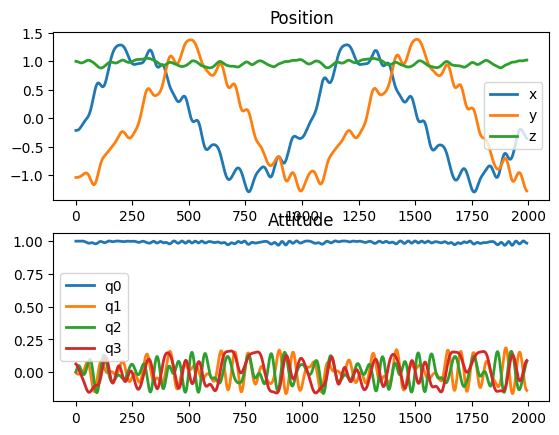

In [42]:
x_all = []
u_all = []
noise_amp = 0

def mpc_tasks():
    def mpc_controller(x, xref_horizon):
        q = x[3:7]
        phi = qtorp(L(qg).T @ q)
        delta_x = np.hstack([x[0:3]-rg, phi, x[7:10]-vg, x[10:13]-omgg])
        noise = np.random.normal(0, 0.01, (n,))*0
        delta_x_noise = delta_x + noise

        prob.set_x0(delta_x_noise)

        xref_matrix = np.array(xref_horizon).T
        prob.set_x_ref(xref_matrix)

        result = prob.solve()
        u_mpc = result['controls']

        return np.array(u_mpc).flatten() + u0
    
    x = Xref[0]
    x[0:3] = Xref[0,0:3] + noise_amp*np.random.randn(3)/10

    print("=== START INTERACTIVE MPC ===")

    NSIM = Nt - N
    for i in range(NSIM):
        u_current = mpc_controller(x, xref[i:i+N])
        
        x = quad_dynamics_rk4(x, u_current)

        u_ = u_current.reshape(4).tolist()
        u_all.append(u_)
        x = x.reshape(n+1).tolist()
        x_all.append(x)

    print(len(x_all))

mpc_tasks()
visualize_trajectory(x_all)

The actual trajectory will be slower than the reference if only position reference trajectory is given (dynamically infeasible), we should provide velocity trajectory via finite difference from the positions.

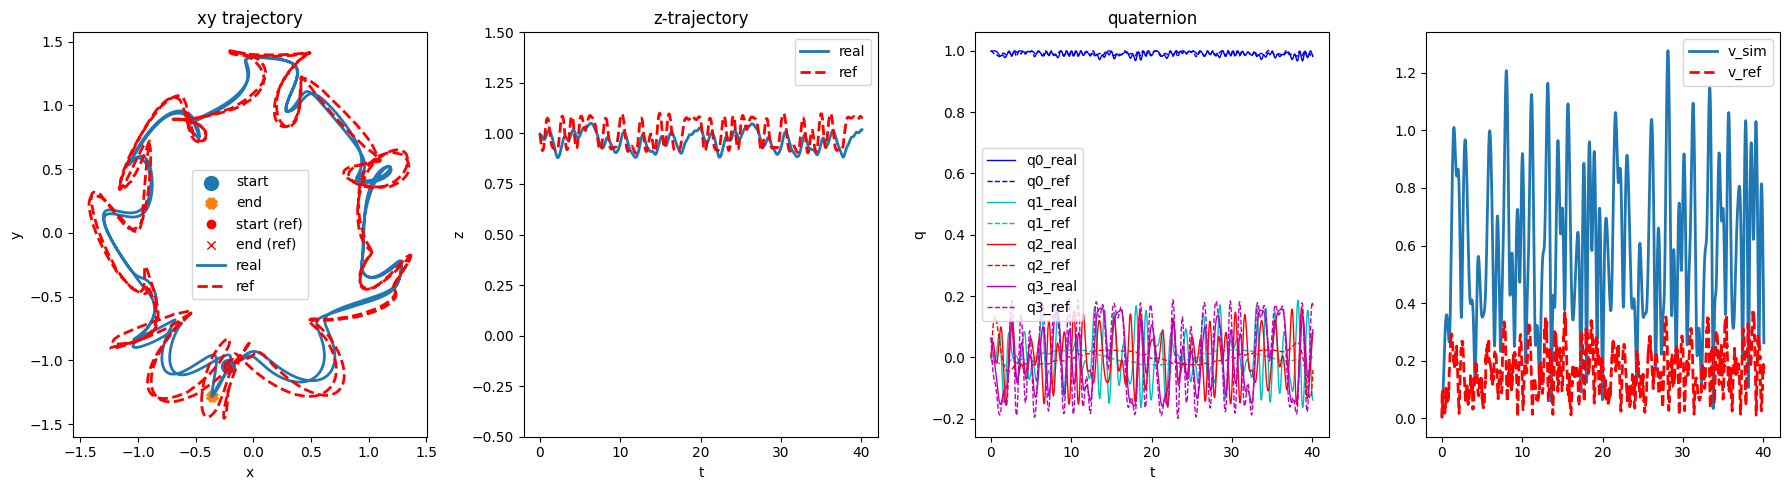

In [43]:
Ns = Nt - N
tt=Tfinal*np.linspace(0,1,Ns)
xa_all = np.array(x_all)
vs = np.linalg.norm(xa_all[:, 7:10], axis=1)
vref = np.linalg.norm(X_ref[0:Nt-N, 6:9], axis=1)

fig, axes = plt.subplots(nrows=1,ncols=4, figsize=(18, 5))

# visualize xy trajectory
axes[0].scatter(xa_all[0, 0], xa_all[0, 1], label="xy", marker="o", linewidth=5)
axes[0].scatter(xa_all[-1, 0], xa_all[-1, 1], label="xy", marker="x", linewidth=5)
axes[0].scatter(X_ref[0, 0], X_ref[0, 1], label="xy", marker="o", linewidth=1, color='red')
axes[0].scatter(X_ref[-1, 0], X_ref[-1, 1], label="xy", marker="x", linewidth=1, color='red')
axes[0].plot(xa_all[:, 0], xa_all[:, 1], label="xy", linewidth=2)
#axes[0].plot(Xref[1:Nt - N, 0], Xref[1:Nt - N, 1], label="xy", linewidth=2, linestyle='dashed', color='red')
axes[0].plot(X_ref[0:Nt - N, 0], X_ref[0:Nt - N, 1], label="xy", linewidth=2, linestyle='dashed', color='red')
axes[0].legend(["start", "end", "start (ref)", "end (ref)", "real", "ref"])
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("xy trajectory")

# z-trajectory
axes[1].plot(tt, xa_all[:, 2], label="xy", linewidth=2)
axes[1].plot(tt, X_ref[0:Nt - N, 2], linewidth=2, linestyle='dashed', color='red')
#axes[1].plot(tt, xa_all[:, 2]-X_ref[0:Nt - N, 2], label="xy", linewidth=2)
axes[1].legend(["real", "ref"])
axes[1].set_xlabel("t")
axes[1].set_ylabel("z")
axes[1].set_ylim(-0.5,1.5)
axes[1].set_title("z-trajectory")

colors = ['b', 'c', 'r', 'm']
for jj in range(4):
    axes[2].plot(tt, xa_all[:, 3+jj], label="xy", linewidth=1, color=colors[jj])
    axes[2].plot(tt, Xref[0:Nt - N, 3+jj], linewidth=1, linestyle='dashed', color=colors[jj])
axes[2].legend(["q0_real", "q0_ref", "q1_real", "q1_ref", "q2_real", "q2_ref", "q3_real", "q3_ref"])
axes[2].set_xlabel("t")
axes[2].set_ylabel("q")
#axes[2].set_ylim(-0.5,1.5)
axes[2].set_title("quaternion")

axes[3].plot(tt, vs, linewidth=2)
axes[3].plot(tt, vref, linewidth=2, linestyle='dashed', color='red')
axes[3].legend(["v_sim", "v_ref"])

plt.tight_layout()
plt.show()

#fig.savefig(f'tmp_traj.png')

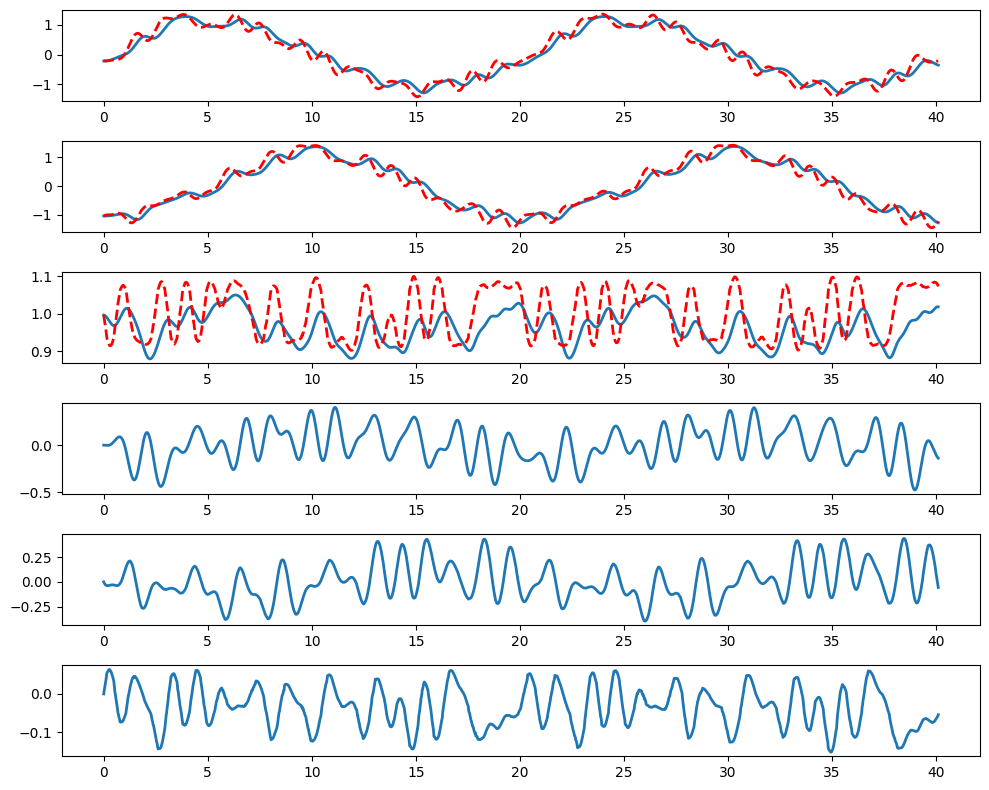

In [44]:
fig, axes = plt.subplots(nrows=6,ncols=1, figsize=(10, 8))
# x-trajectory
axes[0].plot(tt, xa_all[:, 0], label="xy", linewidth=2)
axes[0].plot(tt, X_ref[0:Nt - N, 0], linewidth=2, linestyle='dashed', color='red')
#axes[0,0].set_xlim(0,10)

axes[1].plot(tt, xa_all[:, 1], label="xy", linewidth=2)
axes[1].plot(tt, X_ref[0:Nt - N, 1], linewidth=2, linestyle='dashed', color='red')

axes[2].plot(tt, xa_all[:, 2], label="xy", linewidth=2)
axes[2].plot(tt, X_ref[0:Nt - N, 2], linewidth=2, linestyle='dashed', color='red')

axes[3].plot(tt, xa_all[:, 0]-X_ref[0:Nt - N, 0], label="xy", linewidth=2)
#axes[2].set_xlim(0,10)
axes[4].plot(tt, xa_all[:, 1]-X_ref[0:Nt - N, 1], label="xy", linewidth=2)
axes[5].plot(tt, xa_all[:, 2]-X_ref[0:Nt - N, 2], label="xy", linewidth=2)

plt.tight_layout()
plt.show()

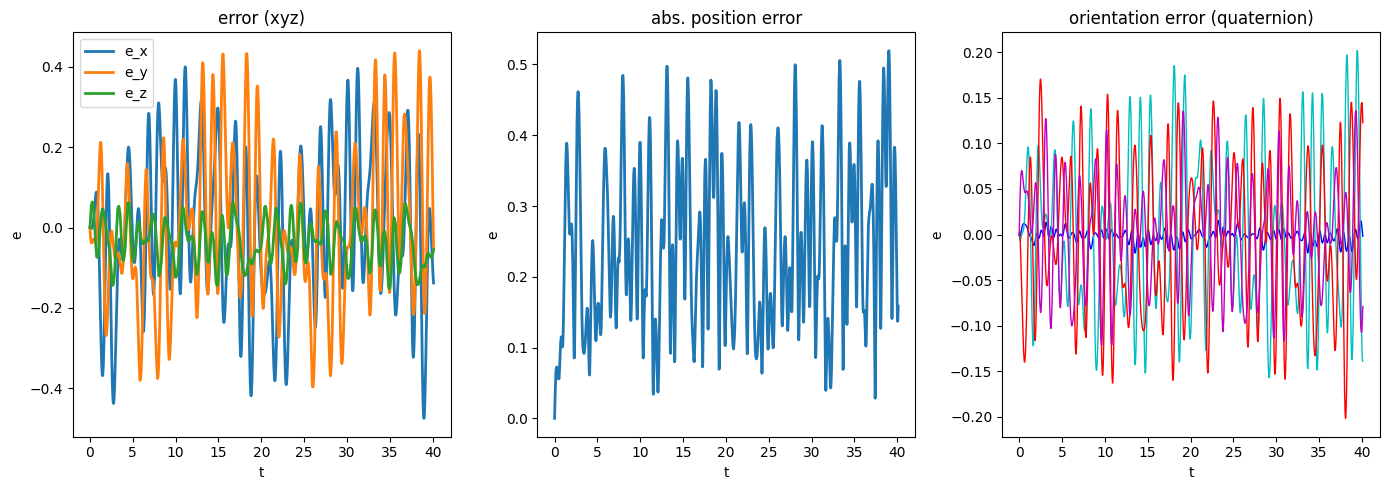

In [45]:

fig, axes = plt.subplots(nrows=1,ncols=3, figsize=(14, 5))

axes[0].plot(tt, xa_all[:, 0]-X_ref[0:Nt - N, 0], label="xy", linewidth=2)
axes[0].plot(tt, xa_all[:, 1]-X_ref[0:Nt - N, 1], label="xy", linewidth=2)
axes[0].plot(tt, xa_all[:, 2]-X_ref[0:Nt - N, 2], label="xy", linewidth=2)
axes[0].legend(["e_x", "e_y", "e_z"])
axes[0].set_xlabel("t")
axes[0].set_ylabel("e")
axes[0].set_title("error (xyz)")

e_pos = np.linalg.norm(xa_all[:, 0:3]-X_ref[0:Nt - N, 0:3], axis=1)
axes[1].plot(tt, e_pos, label="xy", linewidth=2)
axes[1].set_title("abs. position error")
axes[1].set_xlabel("t")
axes[1].set_ylabel("e")

colors = ['b', 'c', 'r', 'm']
for jj in range(4):
    axes[2].plot(tt, xa_all[:, 3+jj]-Xref[0:Nt - N, 3+jj], label="xy", linewidth=1, color=colors[jj])

axes[2].set_title("orientation error (quaternion)")
axes[2].set_xlabel("t")
axes[2].set_ylabel("e")
plt.tight_layout()
plt.show()

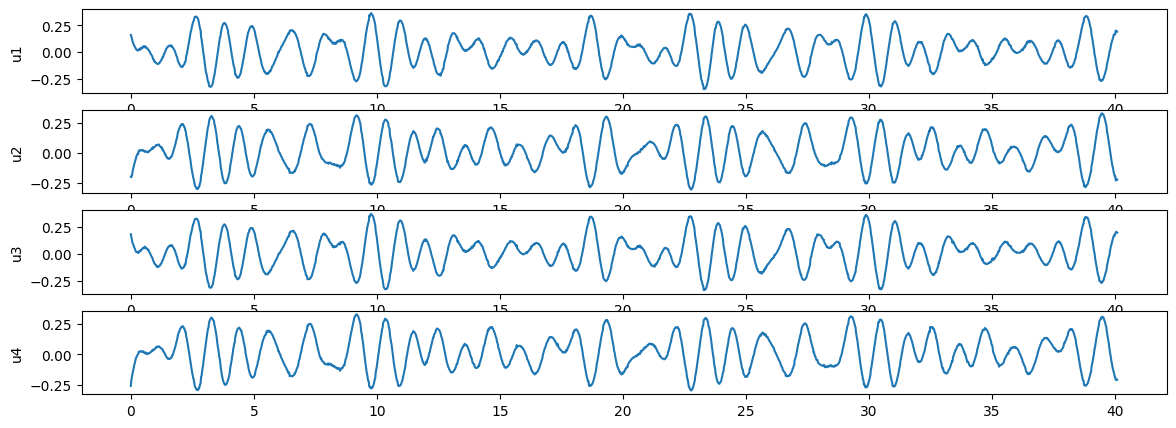

In [46]:
u_ctrl = np.array(u_all)-u0

fig, axes = plt.subplots(nrows=4,ncols=1, figsize=(14, 5))
axes[0].plot(tt,u_ctrl[:,0])
axes[0].set_ylabel("u1")
axes[1].plot(tt,u_ctrl[:,1])
axes[1].set_ylabel("u2")
axes[2].plot(tt,u_ctrl[:,2])
axes[2].set_ylabel("u3")
axes[3].plot(tt,u_ctrl[:,3])
axes[3].set_ylabel("u4")
plt.show()

In [15]:
ua_all = np.array(u_all)

udf = pd.DataFrame(ua_all)

xlab = ['x','y','z','q0','q1','q2','q3','vx','vy','vz','v_phi','v_theta','v_psi']
xdf = pd.DataFrame(xa_all)

In [16]:
udf.to_csv('uref.csv',header=False)
xdf.to_csv('xref.csv',header=False)

## Deployment

OK, everything works well. Let's see how to use the generated code for deployment. We can export the reference to C code for future use.

In [13]:
# Export a vector of vectors to C header
def export_vec_of_vec_to_c(filename, var_type, var_name, data):
    size = len(data)*len(data[0])
    declare = var_type + " " + var_name + "[" + str(size) + "]"
    def_ = declare + " = {\n"
    for i in range(len(data)):
        def_ = def_ + "  "
        for j in range(len(data[0])):
            def_ = def_ + str(data[i][j])
            if j < len(data[0]) - 1:
                def_ = def_ + ","
        if i < len(data) - 1:
            def_ = def_ + ",\n"
    def_ = def_ + "};\n"

    with open(filename + ".hpp", "w") as f:
        f.write(def_)

export_vec_of_vec_to_c("ref_fig8", "tinytype", "Xref_data", xref)

## Deployment

The codegen produces a minimal `tiny_main.cpp` starter template that:
- Prints the problem data (rho, dynamics matrices)
- Calls `tiny_solve()` once
- Reports success/failure

For real deployment, you would modify this file to:
1. Set the initial state from your sensors
2. Update reference trajectories as needed
3. Run in an MPC loop
4. Send control commands to your hardware

See the [TinyMPC documentation](https://tinympc.org/) for deployment examples on embedded platforms.
